# FPAD: Explainability-Guided Knowledge Distillation for Fingerprint Presentation Attack Detection
**Author:** Adarsh Gudipudi (24076703)  
**Supervisor:** Dr. Chidinma Chiejina  
**Dataset:** LivDet 2017 (Digital Persona, GreenBit, CrossMatch)

---
### Pipeline Overview
1. AFQA feature extraction from fingerprint images  
2. TabNet teacher training on tabular features  
3. Projection mechanism: feature importance → spatial relevance maps  
4. ResNet-18 student training via Knowledge Distillation  
5. Ablation study (CE / KD / Explanation Alignment / Full)  
6. Full evaluation: APCER, BPCER, ACER, ECE, ROC-AUC  
7. Cross-sensor generalisation evaluation  
8. Proof of explanation alignment  


## Cell 1 — Install Dependencies

In [5]:
!pip install pytorch-tabnet grad-cam --quiet

## Cell 2 — Imports

In [6]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    log_loss, brier_score_loss, precision_score, recall_score, f1_score
)

from pytorch_tabnet.tab_model import TabNetClassifier
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## Cell 3 — Mount Google Drive & Load Data

In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Load Digital Persona feature CSV
df = pd.read_csv("/content/drive/MyDrive/FPAD_csv/features_digital_persona.csv")
df['path'] = df['path'].astype(str).apply(
    lambda x: x.replace("src/data", "/content/drive/MyDrive/FPAD_images")
)
print(f"Dataset shape: {df.shape}")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (2500, 32)
      gabor  gabor_std       ocl   ocl_std       lcs   lcs_std       fda  \
0  0.949268   0.397001  0.533258  0.098968  0.498546  0.350271  0.271880   
1  0.614105   0.304895  0.613196  0.146199  0.326467  0.376115  0.294855   
2  1.096665   0.537217  0.511172  0.134548  0.530636  0.336741  0.280957   
3  0.675193   0.329324  0.489159  0.097903  0.110392  0.257608  0.233062   
4  1.118175   0.533633  0.517848  0.136127  0.608991  0.312160  0.281915   

    fda_std       rvu   rvu_std  ...       sep   sep_std       mow   mow_std  \
0  0.046689  0.742248  0.392321  ...  1.864635  0.700283  1.804259  0.774032   
1  0.075019  0.561570  0.312277  ...  1.855281  0.971839  1.180728  0.371230   
2  0.068107  0.765048  0.354330  ...  1.997846  0.704625  1.984854  0.985158   
3  0.048290  0.779823  0.415066  ...  2.069433  0.890591  1.284794  

## Cell 4 — Feature Correlation Analysis (RQ1)
Pearson and Spearman correlations between AFQA features and the live/spoof label.  
This directly answers **RQ1**: which quality features provide separability between bona fide and spoof fingerprints.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


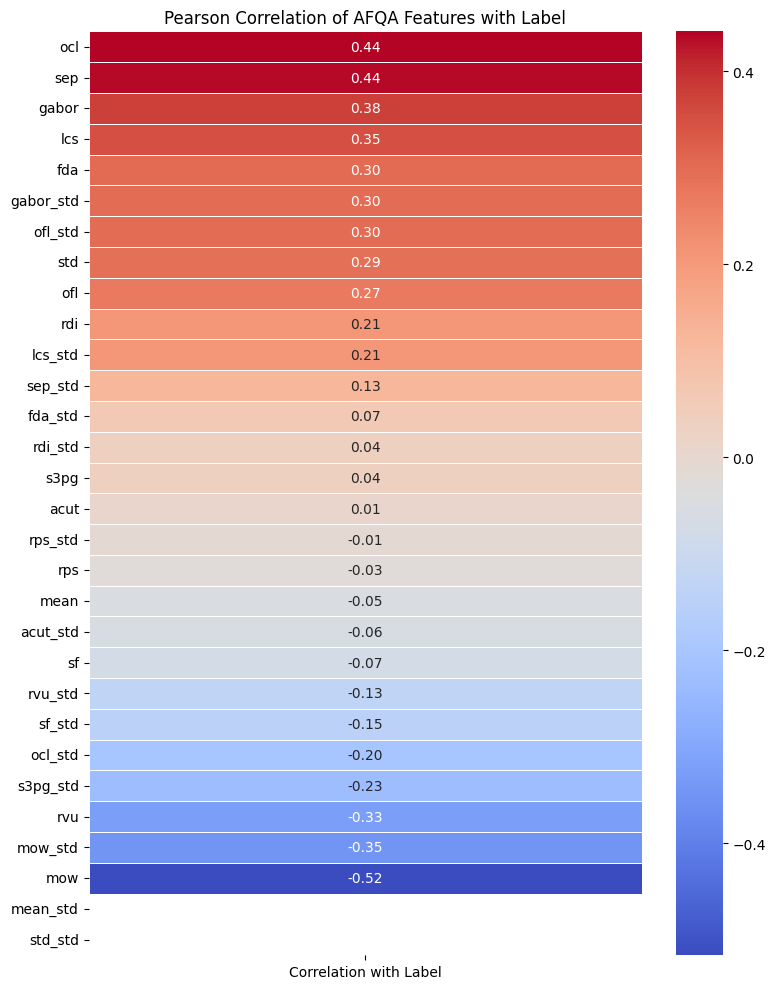

/tmp/ipykernel_821/4201112376.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(df_X[col], y)
/tmp/ipykernel_821/4201112376.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spearman_series.values, y=spearman_series.index, palette='viridis')


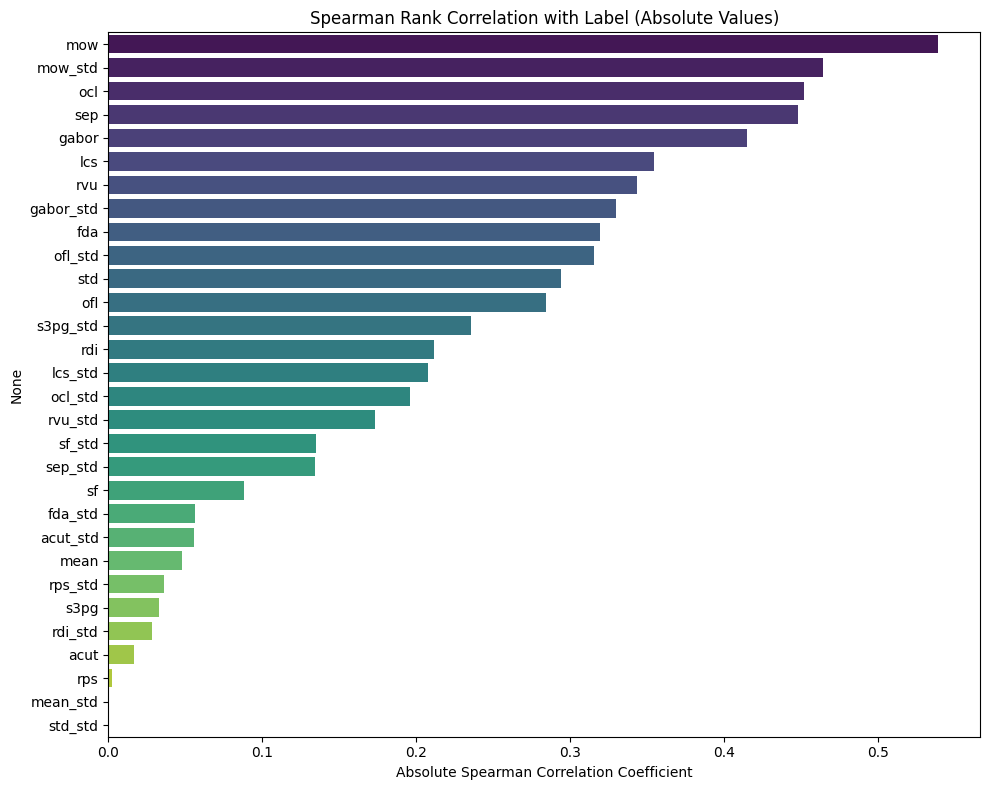

Top 5 discriminative features:
mow        0.539494
mow_std    0.464179
ocl        0.452198
sep        0.448015
gabor      0.415292
dtype: float64


In [8]:
y    = df['label']
df_X = df.drop(['label', 'path'], axis=1)

# Pearson correlation
corr    = df_X.corrwith(y)
corr_df = corr.to_frame(name='Correlation with Label').sort_values(
    by='Correlation with Label', ascending=False
)
plt.figure(figsize=(8, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation of AFQA Features with Label')
plt.tight_layout()
plt.savefig("pearson_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

# Spearman correlation
spearman_corrs = {}
for col in df_X.columns:
    r, _ = spearmanr(df_X[col], y)
    spearman_corrs[col] = r
spearman_series = pd.Series(spearman_corrs).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=spearman_series.values, y=spearman_series.index, palette='viridis')
plt.title('Spearman Rank Correlation with Label (Absolute Values)')
plt.xlabel('Absolute Spearman Correlation Coefficient')
plt.tight_layout()
plt.savefig("spearman_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 discriminative features:")
print(spearman_series.head())

## Cell 5 — Data Cleaning
- Drop low-variance and high-NaN columns  
- Impute remaining NaNs with column mean  
- No data from validation set is used in any cleaning decision

In [9]:
# Drop manually identified low-information columns
df.drop(['mean_std', 'std_std'], axis=1, inplace=True, errors='ignore')

# Drop all-NaN columns
all_nan = df.columns[df.isnull().sum() == len(df)].tolist()
if all_nan:
    print(f"Dropping all-NaN columns: {all_nan}")
    df.drop(columns=all_nan, inplace=True)

# Impute remaining NaNs with column mean
for col in df.columns:
    if df[col].isnull().any() and col not in ['label', 'path']:
        df[col] = df[col].fillna(df[col].mean())

df.dropna(subset=['label'], inplace=True)

print(f"NaN remaining: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")
print(f"Features: {df.drop(columns=['label','path']).columns.tolist()}")

NaN remaining: 0
Final shape: (2500, 30)
Features: ['gabor', 'gabor_std', 'ocl', 'ocl_std', 'lcs', 'lcs_std', 'fda', 'fda_std', 'rvu', 'rvu_std', 'rps', 'rps_std', 'mean', 'std', 'ofl', 'ofl_std', 'rdi', 'rdi_std', 's3pg', 's3pg_std', 'sep', 'sep_std', 'mow', 'mow_std', 'acut', 'acut_std', 'sf', 'sf_std']


## Cell 6 — Synchronised Train/Val Split
The same `random_state=42` split is applied to both the tabular features (for TabNet) and image paths (for ResNet), ensuring perfect alignment between both modalities.

In [10]:
input_dir  = "/content/drive/MyDrive/FPAD_images/Digital_Persona"
valid_ext  = ('.png', '.jpg', '.jpeg', '.bmp')

# Collect image paths (sorted for reproducibility)
image_paths, img_labels = [], []
for label_name in ['Fake', 'Live']:
    folder = os.path.join(input_dir, label_name)
    if not os.path.exists(folder):
        print(f"Warning: {folder} not found")
        continue
    for fname in sorted(os.listdir(folder)):
        if fname.startswith('.') or not fname.lower().endswith(valid_ext):
            continue
        image_paths.append(os.path.join(folder, fname))
        img_labels.append(0 if label_name == 'Fake' else 1)

# Synchronised split — same random_state for both modalities
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

train_images = train_df['path'].tolist()
val_images   = val_df['path'].tolist()
y_train      = train_df['label'].values.astype(int)
y_val        = val_df['label'].values.astype(int)
X_train_raw  = train_df.drop(columns=['label', 'path'])
X_val_raw    = val_df.drop(columns=['label', 'path'])
feature_cols = X_train_raw.columns.tolist()

print(f"Train: {len(train_images)} | Val: {len(val_images)}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

# Scale features — fit ONLY on train, transform val (no data leakage)
scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")

Train: 2000 | Val: 500
Features (28): ['gabor', 'gabor_std', 'ocl', 'ocl_std', 'lcs', 'lcs_std', 'fda', 'fda_std', 'rvu', 'rvu_std', 'rps', 'rps_std', 'mean', 'std', 'ofl', 'ofl_std', 'rdi', 'rdi_std', 's3pg', 's3pg_std', 'sep', 'sep_std', 'mow', 'mow_std', 'acut', 'acut_std', 'sf', 'sf_std']
X_train: (2000, 28) | X_val: (500, 28)


## Cell 7 — Random Forest Baseline

In [11]:
rf_model = RandomForestClassifier(n_estimators=400, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_val, rf_model.predict(X_val))
print(f"Random Forest Accuracy: {rf_acc:.4f}")

df_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(df_imp)

Random Forest Accuracy: 0.9020
      Feature  Importance
22        mow    0.127853
2         ocl    0.079808
20        sep    0.077866
23    mow_std    0.069377
0       gabor    0.055361
7     fda_std    0.045625
6         fda    0.042153
3     ocl_std    0.039934
24       acut    0.038522
14        ofl    0.030763
16        rdi    0.029770
1   gabor_std    0.028462
27     sf_std    0.027328
11    rps_std    0.026088
4         lcs    0.026013
18       s3pg    0.025559
15    ofl_std    0.025102
21    sep_std    0.024139
13        std    0.023876
26         sf    0.022601
12       mean    0.021748
8         rvu    0.021218
10        rps    0.018062
19   s3pg_std    0.016495
5     lcs_std    0.015010
25   acut_std    0.014954
9     rvu_std    0.013739
17    rdi_std    0.012574


## Cell 8 — TabNet Teacher Training
TabNet is selected for its sequential attention mechanism which produces instance-level feature importance masks — the foundation of the projection mechanism.

In [12]:
clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=4, gamma=1.5,
    lambda_sparse=5e-5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.004),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=15, gamma=0.9),
    verbose=10
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=200,
    patience=20,
    batch_size=32,
    virtual_batch_size=32,
    drop_last=False
)

joblib.dump(clf, "tabnet_teacher.pkl")
tabnet_acc = accuracy_score(y_val, clf.predict(X_val))
print(f"TabNet Teacher Validation Accuracy: {tabnet_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.78648 | val_accuracy: 0.746   |  0:00:06s
epoch 10 | loss: 0.35918 | val_accuracy: 0.826   |  0:00:26s
epoch 20 | loss: 0.27386 | val_accuracy: 0.892   |  0:00:44s
epoch 30 | loss: 0.23547 | val_accuracy: 0.914   |  0:01:03s
epoch 40 | loss: 0.19011 | val_accuracy: 0.91    |  0:01:22s
epoch 50 | loss: 0.19256 | val_accuracy: 0.928   |  0:01:41s
epoch 60 | loss: 0.12557 | val_accuracy: 0.916   |  0:01:59s
epoch 70 | loss: 0.12394 | val_accuracy: 0.92    |  0:02:19s

Early stopping occurred at epoch 75 with best_epoch = 55 and best_val_accuracy = 0.932


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Teacher Validation Accuracy: 0.9320


## Cell 9 — TabNet Feature Importance Analysis (RQ1 + RQ3)
Global and class-conditional feature importances reveal which AFQA descriptors TabNet relies on and whether this is consistent with biometric signal theory.

TabNet Global Feature Importances:
mow          0.1925
gabor        0.1040
mean         0.0872
rdi_std      0.0866
sep          0.0654
ocl          0.0583
lcs_std      0.0546
fda_std      0.0518
rvu          0.0410
sf           0.0336
gabor_std    0.0335
rdi          0.0247
acut         0.0245
rps          0.0238
ofl_std      0.0230
s3pg         0.0184
sep_std      0.0143
lcs          0.0136
mow_std      0.0096
ocl_std      0.0090
sf_std       0.0071
fda          0.0064
std          0.0050
rvu_std      0.0041
rps_std      0.0035
acut_std     0.0029
ofl          0.0015
s3pg_std     0.0001
dtype: float64


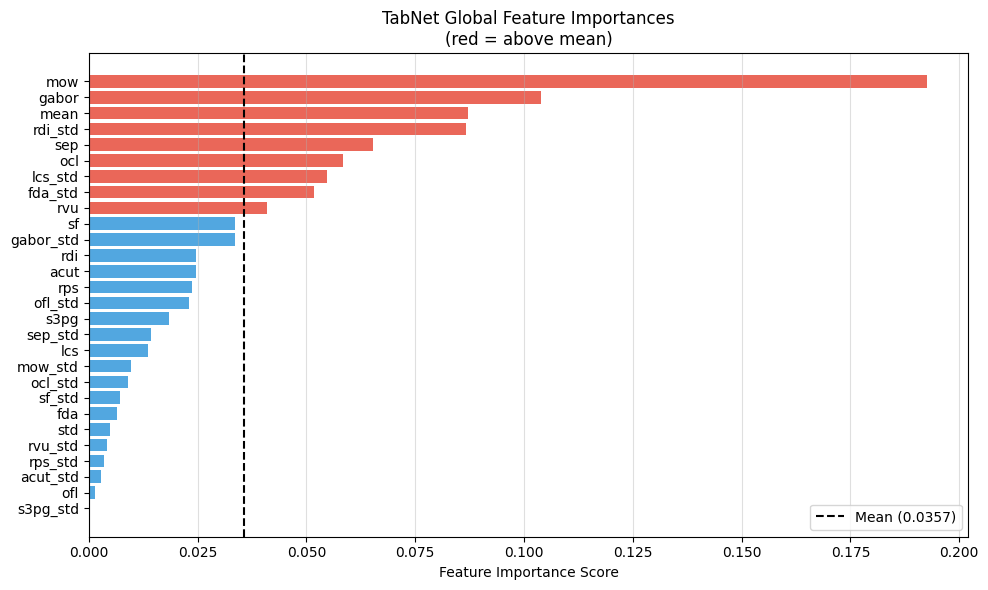

Teacher probs shape — train: (2000, 2), val: (500, 2)


In [13]:
# Global importances
importance_global = pd.Series(
    clf.feature_importances_, index=feature_cols
).sort_values(ascending=False)

print("TabNet Global Feature Importances:")
print(importance_global.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
colours = ['#e74c3c' if v > importance_global.mean() else '#3498db'
           for v in importance_global.values]
ax.barh(importance_global.index[::-1], importance_global.values[::-1],
        color=colours[::-1], alpha=0.85)
ax.axvline(importance_global.mean(), color='black', linestyle='--',
           label=f'Mean ({importance_global.mean():.4f})')
ax.set_xlabel("Feature Importance Score")
ax.set_title("TabNet Global Feature Importances\n(red = above mean)")
ax.legend(); ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig("feature_importance_global.png", dpi=150, bbox_inches='tight')
plt.show()

# Extract teacher soft probabilities
teacher_train_probs = clf.predict_proba(X_train)
teacher_val_probs   = clf.predict_proba(X_val)
print(f"Teacher probs shape — train: {teacher_train_probs.shape}, val: {teacher_val_probs.shape}")

## Cell 10 — Projection Mechanism: Feature Importance → Spatial Relevance Maps
**Core novelty of this work.** TabNet's instance-level feature importance vector (28 values) is projected onto a spatial block grid using biometric-theory-grounded Gaussian templates, then upsampled to 224×224.

This bridges the modality gap between the tabular teacher and image-based student.

Building relevance maps for TRAIN set...
  Samples: 2000 | Features: 28 | Grid: 15x15
  Explained 256/2000 ...
  Done. Shape: (2000, 224, 224)

Building relevance maps for VAL set...
  Samples: 500 | Features: 28 | Grid: 15x15
  Explained 256/500 ...
  Done. Shape: (500, 224, 224)
Saved relevance maps.


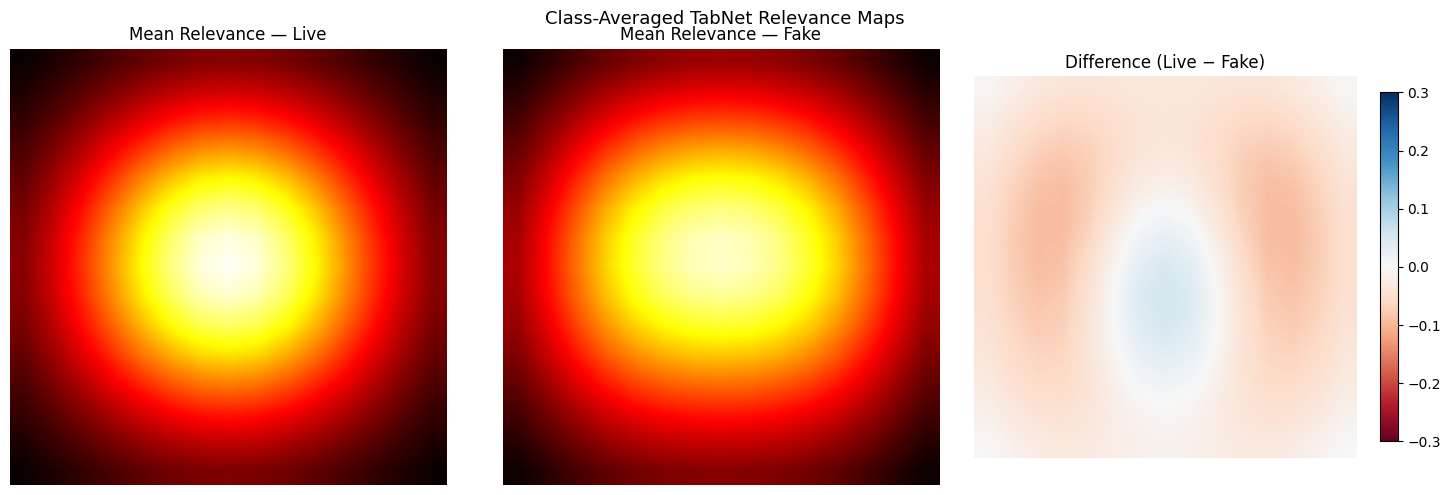

In [14]:
def get_importance_matrix(tabnet_model, X_batch, num_feats):
    """Robustly extract (batch, num_feats) importance matrix from clf.explain()."""
    batch_size = X_batch.shape[0]
    fallback   = np.ones((batch_size, num_feats), dtype=np.float32) / num_feats
    try:
        masks, agg = tabnet_model.explain(X_batch)
    except Exception as e:
        print(f"  explain() failed: {e}. Using uniform importance.")
        return fallback

    candidates = []
    for obj in [masks, agg]:
        if isinstance(obj, np.ndarray):
            candidates.append(obj.astype(np.float32))
        elif isinstance(obj, dict):
            arrs = [np.array(v, dtype=np.float32) for v in obj.values()]
            if arrs:
                candidates.append(np.mean(np.stack(arrs, axis=0), axis=0))
        elif isinstance(obj, list):
            arrs = [np.array(m, dtype=np.float32) for m in obj]
            if arrs:
                candidates.append(np.mean(np.stack(arrs, axis=0), axis=0))

    for arr in candidates:
        if arr.ndim == 1:
            if arr.shape[0] == num_feats:
                arr = np.tile(arr, (batch_size, 1))
            else:
                continue
        elif arr.ndim == 2:
            if arr.shape == (batch_size, num_feats):
                pass
            elif arr.shape == (num_feats, batch_size):
                arr = arr.T
            elif arr.shape[0] == batch_size:
                if arr.shape[1] > num_feats:
                    arr = arr[:, :num_feats]
                else:
                    pad = np.zeros((batch_size, num_feats - arr.shape[1]), dtype=np.float32)
                    arr = np.concatenate([arr, pad], axis=1)
            else:
                continue
        elif arr.ndim == 3:
            arr = arr.mean(axis=0)
            if arr.shape != (batch_size, num_feats):
                continue
        else:
            continue
        row_sums = arr.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1.0, row_sums)
        return (arr / row_sums).astype(np.float32)

    return fallback


def get_feature_spatial_weights(feature_names, importance_vec, n_blocks=15):
    """
    Maps feature importances onto spatial block grid using biometric Gaussian templates.
    OCL/orientation → central core | FDA → lower arch | RVU → lateral bands
    Grounded in ISO/IEC 29794-4 fingerprint quality theory.
    """
    cy, cx = n_blocks // 2, n_blocks // 2

    def gaussian_blob(cy, cx, sy=3.0, sx=3.0):
        g = np.zeros((n_blocks, n_blocks), dtype=np.float32)
        for r in range(n_blocks):
            for c in range(n_blocks):
                g[r, c] = np.exp(-((r-cy)**2/(2*sy**2) + (c-cx)**2/(2*sx**2)))
        peak = g.max()
        return g / peak if peak > 0 else g

    templates = {
        'ocl':  gaussian_blob(cy, cx, 2.5, 2.5),
        'ofl':  gaussian_blob(cy, cx, 3.5, 3.5),
        'lcs':  gaussian_blob(cy, cx, 5.0, 5.0),
        'gab':  gaussian_blob(cy-2, cx, 3.0, 3.5),
        'gsh':  gaussian_blob(cy-2, cx, 3.0, 3.5),
        'fda':  gaussian_blob(cy+2, cx, 3.0, 5.0),
        'rvu':  np.clip(gaussian_blob(cy, cx-4, 4.0, 2.0) +
                        gaussian_blob(cy, cx+4, 4.0, 2.0), 0, 1),
        'rps':  gaussian_blob(cy, cx, 5.0, 5.0),
        'mean': gaussian_blob(cy, cx, 6.0, 6.0),
        'std':  gaussian_blob(cy, cx, 6.0, 6.0),
    }
    default_tmpl = gaussian_blob(cy, cx, 4.0, 4.0)

    grid = np.zeros((n_blocks, n_blocks), dtype=np.float32)
    for f_idx, fname in enumerate(feature_names):
        imp = float(importance_vec[f_idx])
        if imp <= 0:
            continue
        fname_lower = fname.lower()
        matched = next((k for k in templates if k in fname_lower), None)
        tmpl = templates[matched] if matched else default_tmpl
        grid += imp * tmpl

    gmin, gmax = grid.min(), grid.max()
    if gmax > gmin:
        grid = (grid - gmin) / (gmax - gmin)
    else:
        grid = np.ones_like(grid) * 0.5
    return grid


def build_relevance_maps(X_scaled, feature_names, tabnet_model,
                          image_size=(224, 224), block_size=32,
                          fingerprint_size=500, batch_size=256):
    """
    Builds one (H, W) spatial relevance map per sample.
    Projects TabNet feature importance onto biometric spatial templates.
    """
    n_blocks  = fingerprint_size // block_size
    N         = X_scaled.shape[0]
    num_feats = len(feature_names)
    print(f"  Samples: {N} | Features: {num_feats} | Grid: {n_blocks}x{n_blocks}")

    all_importance = np.zeros((N, num_feats), dtype=np.float32)
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        all_importance[start:end] = get_importance_matrix(
            tabnet_model, X_scaled[start:end], num_feats
        )
        if start % 500 == 0:
            print(f"  Explained {end}/{N} ...")

    relevance_maps = np.zeros((N, image_size[0], image_size[1]), dtype=np.float32)
    for i in range(N):
        importance_vec = all_importance[i]
        feat_vals      = X_scaled[i].astype(np.float32)
        fmin, fmax     = feat_vals.min(), feat_vals.max()
        feat_norm      = (feat_vals - fmin) / (fmax - fmin + 1e-8)
        weighted_imp   = importance_vec * feat_norm
        grid           = get_feature_spatial_weights(feature_names, weighted_imp, n_blocks)
        grid_t         = torch.tensor(grid).unsqueeze(0).unsqueeze(0)
        upsampled      = F.interpolate(grid_t, size=image_size,
                                        mode='bilinear', align_corners=False
                                       ).squeeze().numpy()
        relevance_maps[i] = upsampled

    print(f"  Done. Shape: {relevance_maps.shape}")
    return relevance_maps


print("Building relevance maps for TRAIN set...")
train_relevance_maps = build_relevance_maps(X_train, feature_cols, clf)

print("\nBuilding relevance maps for VAL set...")
val_relevance_maps = build_relevance_maps(X_val, feature_cols, clf)

np.save("train_relevance_maps.npy", train_relevance_maps)
np.save("val_relevance_maps.npy",   val_relevance_maps)
print("Saved relevance maps.")

# Visualise class-averaged maps
live_idx = np.where(y_train == 1)[0][:4]
fake_idx = np.where(y_train == 0)[0][:4]
mean_live = train_relevance_maps[y_train == 1].mean(axis=0)
mean_fake = train_relevance_maps[y_train == 0].mean(axis=0)
diff_map  = mean_live - mean_fake

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mean_live, cmap='hot', vmin=0, vmax=1)
axes[0].set_title("Mean Relevance — Live"); axes[0].axis('off')
axes[1].imshow(mean_fake, cmap='hot', vmin=0, vmax=1)
axes[1].set_title("Mean Relevance — Fake"); axes[1].axis('off')
im = axes[2].imshow(diff_map, cmap='RdBu', vmin=-0.3, vmax=0.3)
axes[2].set_title("Difference (Live − Fake)"); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], shrink=0.8)
plt.suptitle("Class-Averaged TabNet Relevance Maps", fontsize=13)
plt.tight_layout()
plt.savefig("relevance_maps_class_avg.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Dataset and DataLoaders

In [15]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


class FPADDataset(Dataset):
    """Returns (image, label, teacher_soft_probs, relevance_map)."""
    def __init__(self, image_paths, labels, transform,
                 teacher_probs=None, relevance_maps=None):
        self.image_paths    = image_paths
        self.labels         = labels
        self.transform      = transform
        self.teacher_probs  = teacher_probs
        self.relevance_maps = relevance_maps

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((224, 224), dtype=np.uint8)
        img   = self.transform(img)
        label = int(self.labels[idx])
        teacher = torch.tensor(
            self.teacher_probs[idx], dtype=torch.float32
        ) if self.teacher_probs is not None else torch.zeros(2)
        if self.relevance_maps is not None:
            rel = np.array(self.relevance_maps[idx], dtype=np.float32)
            if rel.ndim == 2:
                rel = rel[np.newaxis, :, :]
            rel_map = torch.tensor(rel)
        else:
            rel_map = torch.zeros(1, 7, 7)
        return img, label, teacher, rel_map


# Precompute 7x7 relevance maps for fast training
def downsample_maps(maps_224, small_size=7):
    N   = maps_224.shape[0]
    out = np.zeros((N, small_size, small_size), dtype=np.float32)
    for i in range(0, N, 256):
        end   = min(i + 256, N)
        batch = torch.tensor(maps_224[i:end]).unsqueeze(1)
        small = F.interpolate(batch, size=(small_size, small_size),
                               mode='bilinear', align_corners=False)
        out[i:end] = small.squeeze(1).numpy()
    return out

train_rel_small = downsample_maps(train_relevance_maps, 7)
val_rel_small   = downsample_maps(val_relevance_maps,   7)

train_kd_dataset_fast = FPADDataset(
    train_images, y_train, train_transform,
    teacher_probs=teacher_train_probs, relevance_maps=train_rel_small)
val_kd_dataset_fast = FPADDataset(
    val_images, y_val, val_transform,
    teacher_probs=teacher_val_probs, relevance_maps=val_rel_small)
train_raw_dataset = FPADDataset(train_images, y_train, train_transform)
val_raw_dataset   = FPADDataset(val_images,   y_val,   val_transform)

# num_workers=0 — avoids Colab multiprocessing deadlock
train_kd_loader_fast  = DataLoader(train_kd_dataset_fast,  batch_size=32, shuffle=True,  num_workers=0)
val_kd_loader_fast    = DataLoader(val_kd_dataset_fast,    batch_size=32, shuffle=False, num_workers=0)
train_raw_loader      = DataLoader(train_raw_dataset,      batch_size=32, shuffle=True,  num_workers=0)
val_raw_loader        = DataLoader(val_raw_dataset,        batch_size=32, shuffle=False, num_workers=0)

# Sanity check
imgs, labels, teacher, rel = next(iter(train_kd_loader_fast))
print(f"Batch — img:{imgs.shape} labels:{labels.shape} teacher:{teacher.shape} rel:{rel.shape}")
# Expected: img(32,1,224,224) labels(32,) teacher(32,2) rel(32,1,7,7)

Batch — img:torch.Size([32, 1, 224, 224]) labels:torch.Size([32]) teacher:torch.Size([32, 2]) rel:torch.Size([32, 1, 7, 7])


## Cell 12 — ResNet-18 Model, Loss Functions & Training Utilities
**ActivationCAM** is used instead of Grad-CAM during training to avoid double-backward interference.  
**Composite loss** = α·CE + β·KD + γ·ExplanationAlignment

In [16]:
class ResNet18FPAD(nn.Module):
    """ResNet-18 adapted for grayscale fingerprint input (1 channel)."""
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc    = nn.Linear(self.model.fc.in_features, 2)

    def forward(self, x):
        return self.model(x)

    def get_gradcam_layer(self):
        return self.model.layer4[-1]


class FastActivationCAM:
    """
    Lightweight CAM using only forward activations (no backward).
    Safe inside training loop — no computation graph interference.
    Returns (B, 1, 7, 7) maps matching layer4 spatial resolution.
    """
    def __init__(self, model):
        self.model       = model
        self.activations = None
        model.get_gradcam_layer().register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o)
        )

    def get_cam(self):
        act = self.activations.detach()
        cam = F.relu(act.mean(dim=1, keepdim=True))
        B        = cam.shape[0]
        cam_flat = cam.view(B, -1)
        cmin     = cam_flat.min(dim=1).values.view(B, 1, 1, 1)
        cmax     = cam_flat.max(dim=1).values.view(B, 1, 1, 1)
        return (cam - cmin) / (cmax - cmin + 1e-8)


def kd_logit_loss(student_logits, teacher_probs, T=4.0):
    """Hinton et al. 2015 KL-divergence distillation loss."""
    student_log_soft = F.log_softmax(student_logits / T, dim=1)
    teacher_probs    = teacher_probs.clamp(min=1e-8)
    teacher_soft     = F.softmax(torch.log(teacher_probs) / T, dim=1)
    return F.kl_div(student_log_soft, teacher_soft, reduction='batchmean') * (T ** 2)


def train_epoch_fast(model,cam_extractor,loader,optimizer,epoch,
                     alpha=0.5,beta=0.3,gamma=0.2,T=4.0):
    model.train()
    totals = {'loss': 0.0, 'ce': 0.0, 'kd': 0.0, 'exp': 0.0}
    n = len(loader)

    for imgs, labels, teacher_probs, rel_maps in loader:
        imgs          = imgs.to(device)
        labels        = labels.to(device)
        teacher_probs = teacher_probs.to(device)
        rel_maps      = rel_maps.to(device)   # (B, 1, 7, 7)

        optimizer.zero_grad()
        logits  = model(imgs)
        ce_loss = F.cross_entropy(logits, labels)

        if epoch < 5:
            loss = ce_loss
            totals['ce']   += ce_loss.item()
            totals['loss'] += loss.item()
        else:
            cam      = cam_extractor.get_cam()    # (B, 1, 7, 7)
            kd_loss  = kd_logit_loss(logits, teacher_probs, T)
            exp_loss = F.mse_loss(cam, rel_maps)  # spatial alignment
            loss     = alpha * ce_loss + beta * kd_loss + gamma * exp_loss
            totals['ce']   += ce_loss.item()
            totals['kd']   += kd_loss.item()
            totals['exp']  += exp_loss.item()
            totals['loss'] += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    return (totals['loss']/n, totals['ce']/n, totals['kd']/n, totals['exp']/n)


def train_epoch_raw(model, loader, optimizer):
    model.train()
    total = 0.0
    for imgs, labels, _, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(imgs), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total += loss.item()
    avg = total / len(loader)
    return avg, avg, 0.0, 0.0


def evaluate_model(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels, _, _ in loader:
            imgs = imgs.to(device)
            preds.extend(torch.argmax(model(imgs), dim=1).cpu().numpy())
            targets.extend(labels.numpy())
    return accuracy_score(targets, preds)


def make_opt_sch(model, lr=1e-4, wd=1e-4):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    return opt, sch


def run_training(name, model, train_fn, val_loader,
                 optimizer, scheduler, num_epochs=40,
                 patience=8, save_path="best.pth"):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    best_acc, no_improve = 0.0, 0
    history = []
    for epoch in range(num_epochs):
        t0        = time.time()
        loss_info = train_fn(epoch=epoch)
        val_acc   = evaluate_model(model, val_loader)
        scheduler.step(val_acc)
        total, ce, kd, exp = loss_info
        print(f"Ep {epoch:02d} | {time.time()-t0:.0f}s | loss={total:.4f} "
              f"(ce={ce:.4f} kd={kd:.4f} exp={exp:.4f}) | val={val_acc:.4f}")
        history.append({'epoch': epoch, 'val_acc': val_acc,
                        'loss': total, 'ce': ce, 'kd': kd, 'exp': exp})
        if val_acc > best_acc:
            best_acc, no_improve = val_acc, 0
            torch.save(model.state_dict(), save_path)
            print(f"         ✓ saved ({val_acc:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stop at epoch {epoch}")
                break
    model.load_state_dict(torch.load(save_path))
    print(f"Best val acc: {best_acc:.4f}")
    return model, history, best_acc

## Cell 13 — Ablation Study
Four conditions isolate the contribution of each loss component:
- **A:** Raw ResNet-18 (CE only) — baseline
- **B:** ResNet-18 + Logit KD (soft label matching)
- **C:** ResNet-18 + Explanation Alignment only (spatial attention supervision)
- **D:** Full Model (CE + KD + Explanation Alignment)

In [17]:
results_summary = {}

# ── A: Raw ResNet (CE only) ───────────────────────────────────────────────────
model_A = ResNet18FPAD().to(device)
opt_A, sch_A = make_opt_sch(model_A)
model_A, history_A, acc_A = run_training(
    "A: Raw ResNet18 (CE only)", model_A,
    train_fn=lambda epoch: train_epoch_raw(model_A, train_raw_loader, opt_A),
    val_loader=val_raw_loader, optimizer=opt_A, scheduler=sch_A,
    num_epochs=40, patience=8, save_path="best_A.pth"
)
results_summary['A: Raw ResNet'] = acc_A

# ── B: KD only (gamma=0) ─────────────────────────────────────────────────────
model_B = ResNet18FPAD().to(device)
cam_B   = FastActivationCAM(model_B)
opt_B, sch_B = make_opt_sch(model_B)
model_B, history_B, acc_B = run_training(
    "B: ResNet + KD only", model_B,
    train_fn=lambda epoch: train_epoch_fast(
        model_B, cam_B, train_kd_loader_fast, opt_B, epoch,
        alpha=0.5, beta=0.5, gamma=0.0),
    val_loader=val_kd_loader_fast, optimizer=opt_B, scheduler=sch_B,
    num_epochs=40, patience=8, save_path="best_B.pth"
)
results_summary['B: KD only'] = acc_B

# ── C: Explanation only (beta=0) ─────────────────────────────────────────────
model_C = ResNet18FPAD().to(device)
cam_C   = FastActivationCAM(model_C)
opt_C, sch_C = make_opt_sch(model_C)
model_C, history_C, acc_C = run_training(
    "C: ResNet + Explanation Alignment only", model_C,
    train_fn=lambda epoch: train_epoch_fast(
        model_C, cam_C, train_kd_loader_fast, opt_C, epoch,
        alpha=0.7, beta=0.0, gamma=0.3),
    val_loader=val_kd_loader_fast, optimizer=opt_C, scheduler=sch_C,
    num_epochs=40, patience=8, save_path="best_C.pth"
)
results_summary['C: Exp only'] = acc_C

# ── D: Full model ─────────────────────────────────────────────────────────────
model_D = ResNet18FPAD().to(device)
cam_D   = FastActivationCAM(model_D)
opt_D, sch_D = make_opt_sch(model_D)
model_D, history_D, acc_D = run_training(
    "D: Full Model (CE + KD + Exp)", model_D,
    train_fn=lambda epoch: train_epoch_fast(
        model_D, cam_D, train_kd_loader_fast, opt_D, epoch,
        alpha=0.5, beta=0.3, gamma=0.2),
    val_loader=val_kd_loader_fast, optimizer=opt_D, scheduler=sch_D,
    num_epochs=40, patience=8, save_path="best_D.pth"
)
results_summary['D: Full Model'] = acc_D

print("\n" + "="*45)
print("ABLATION SUMMARY")
print("="*45)
for name, acc in results_summary.items():
    print(f"  {name:35s}: {acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]



A: Raw ResNet18 (CE only)
Ep 00 | 970s | loss=0.3513 (ce=0.3513 kd=0.0000 exp=0.0000) | val=0.9140
         ✓ saved (0.9140)
Ep 01 | 30s | loss=0.2233 (ce=0.2233 kd=0.0000 exp=0.0000) | val=0.9320
         ✓ saved (0.9320)
Ep 02 | 30s | loss=0.1929 (ce=0.1929 kd=0.0000 exp=0.0000) | val=0.9220
Ep 03 | 30s | loss=0.1690 (ce=0.1690 kd=0.0000 exp=0.0000) | val=0.9320
Ep 04 | 30s | loss=0.1002 (ce=0.1002 kd=0.0000 exp=0.0000) | val=0.9620
         ✓ saved (0.9620)
Ep 05 | 30s | loss=0.1006 (ce=0.1006 kd=0.0000 exp=0.0000) | val=0.9560
Ep 06 | 30s | loss=0.0766 (ce=0.0766 kd=0.0000 exp=0.0000) | val=0.9640
         ✓ saved (0.9640)
Ep 07 | 30s | loss=0.0807 (ce=0.0807 kd=0.0000 exp=0.0000) | val=0.9560
Ep 08 | 30s | loss=0.0795 (ce=0.0795 kd=0.0000 exp=0.0000) | val=0.9820
         ✓ saved (0.9820)
Ep 09 | 30s | loss=0.0782 (ce=0.0782 kd=0.0000 exp=0.0000) | val=0.9700
Ep 10 | 30s | loss=0.0649 (ce=0.0649 kd=0.0000 exp=0.0000) | val=0.9360
Ep 11 | 30s | loss=0.0450 (ce=0.0450 kd=0.0000 exp

## Cell 14 — Full Evaluation
Computes APCER, BPCER, ACER, ROC-AUC, ECE, NLL, Brier score for all five models.  
Produces: metrics table, ROC curves, reliability diagrams, confusion matrices, bar chart comparison.


  TabNet Teacher
  Accuracy    : 0.9320
  Precision   : 0.9511
  Recall      : 0.8750
  F1          : 0.9115
  APCER       : 0.0300
  BPCER       : 0.1250
  ACER        : 0.0775
  ROC_AUC     : 0.9748
  NLL         : 0.2011
  Brier       : 0.0562
  ECE         : 0.0329

  A: Raw ResNet18
  Accuracy    : 0.9980
  Precision   : 0.9950
  Recall      : 1.0000
  F1          : 0.9975
  APCER       : 0.0033
  BPCER       : 0.0000
  ACER        : 0.0017
  ROC_AUC     : 0.9995
  NLL         : 0.0210
  Brier       : 0.0038
  ECE         : 0.0053

  B: ResNet + KD
  Accuracy    : 0.9920
  Precision   : 0.9900
  Recall      : 0.9900
  F1          : 0.9900
  APCER       : 0.0067
  BPCER       : 0.0100
  ACER        : 0.0083
  ROC_AUC     : 0.9997
  NLL         : 0.0437
  Brier       : 0.0090
  ECE         : 0.0253

  C: ResNet + Exp
  Accuracy    : 0.9840
  Precision   : 0.9800
  Recall      : 0.9800
  F1          : 0.9800
  APCER       : 0.0133
  BPCER       : 0.0200
  ACER        : 0.0167
  ROC_

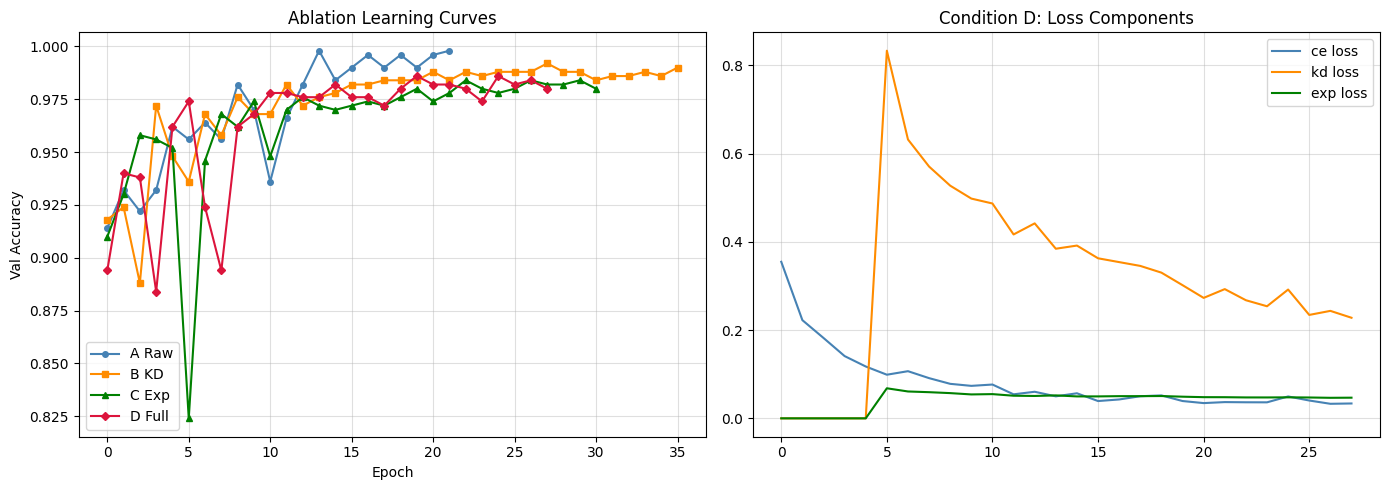

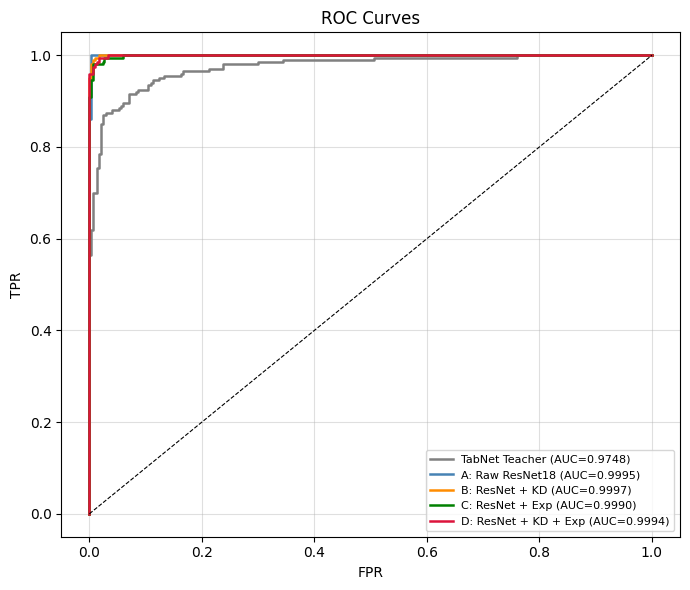

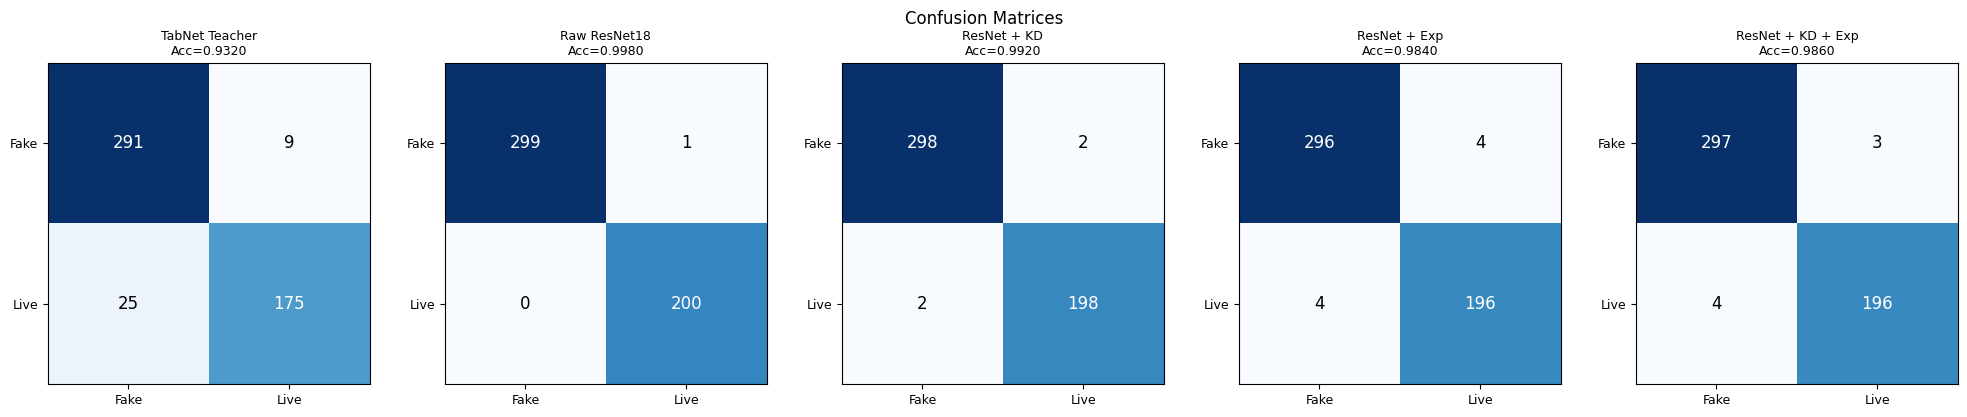


Saved: evaluation_results.csv, learning_curves.png, roc_curves.png, confusion_matrices.png


In [18]:
def compute_all_metrics(y_true, y_pred, y_prob):
    y_true, y_pred, y_prob = np.array(y_true).astype(int), np.array(y_pred).astype(int), np.array(y_prob).astype(float)
    fake_mask, live_mask   = (y_true == 0), (y_true == 1)
    APCER = np.mean(y_pred[fake_mask] == 1) if fake_mask.any() else np.nan
    BPCER = np.mean(y_pred[live_mask] == 0) if live_mask.any() else np.nan
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'APCER': APCER, 'BPCER': BPCER, 'ACER': (APCER + BPCER) / 2,
        'ROC_AUC':   roc_auc_score(y_true, y_prob),
        'NLL':       log_loss(y_true, np.column_stack([1 - y_prob, y_prob])),
        'Brier':     brier_score_loss(y_true, y_prob),
    }

def ece_score(y_true, y_prob, n_bins=10):
    y_true, y_prob = np.array(y_true).astype(int), np.array(y_prob).astype(float)
    confs, preds   = np.maximum(y_prob, 1 - y_prob), (y_prob >= 0.5).astype(int)
    edges, ece     = np.linspace(0, 1, n_bins + 1), 0.0
    for i in range(n_bins):
        mask = (confs >= edges[i]) & (confs < edges[i + 1])
        if mask.any():
            ece += np.abs(np.mean(preds[mask] == y_true[mask]) - np.mean(confs[mask])) * mask.mean()
    return ece

def get_torch_outputs(model, loader):
    model.eval()
    yt, yp, ypr = [], [], []
    with torch.no_grad():
        for imgs, labels, _, _ in loader:
            probs = torch.softmax(model(imgs.to(device)), dim=1)
            yt.extend(labels.numpy()); yp.extend(probs.argmax(1).cpu().numpy())
            ypr.extend(probs[:, 1].cpu().numpy())
    return np.array(yt), np.array(yp), np.array(ypr)

def get_tabnet_outputs(m, X, y):
    probs = m.predict_proba(X)
    return np.array(y).astype(int), probs.argmax(1), probs[:, 1]

# Collect outputs
all_outputs = {
    'TabNet Teacher':        get_tabnet_outputs(clf, X_val, y_val),
    'A: Raw ResNet18':       get_torch_outputs(model_A, val_raw_loader),
    'B: ResNet + KD':        get_torch_outputs(model_B, val_kd_loader_fast),
    'C: ResNet + Exp':       get_torch_outputs(model_C, val_kd_loader_fast),
    'D: ResNet + KD + Exp':  get_torch_outputs(model_D, val_kd_loader_fast),
}

# Compute metrics
rows = []
for name, (yt, yp, ypr) in all_outputs.items():
    m = compute_all_metrics(yt, yp, ypr)
    m['ECE'] = ece_score(yt, ypr); m['Model'] = name
    rows.append(m)
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    for k, v in m.items():
        if k != 'Model': print(f"  {k:12s}: {v:.4f}")

cols       = ['Model','Accuracy','F1','APCER','BPCER','ACER','ROC_AUC','ECE','NLL','Brier']
results_df = pd.DataFrame(rows)[cols].sort_values('ACER')
print("\n" + "="*70)
print("SUMMARY TABLE (sorted by ACER ↓)")
print("="*70)
print(results_df.to_string(index=False, float_format="{:.4f}".format))
results_df.to_csv("evaluation_results.csv", index=False)

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lbl, hist, c, mk in [('A Raw',    history_A,'steelblue','o'),
                           ('B KD',     history_B,'darkorange','s'),
                           ('C Exp',    history_C,'green','^'),
                           ('D Full',   history_D,'crimson','D')]:
    axes[0].plot([h['epoch'] for h in hist],[h['val_acc'] for h in hist],
                 marker=mk, markersize=4, color=c, label=lbl, linewidth=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Accuracy")
axes[0].set_title("Ablation Learning Curves"); axes[0].legend(); axes[0].grid(True,alpha=0.4)
for k, c in [('ce','steelblue'),('kd','darkorange'),('exp','green')]:
    axes[1].plot([h['epoch'] for h in history_D],[h[k] for h in history_D],
                 color=c, label=f'{k} loss', linewidth=1.5)
axes[1].set_title("Condition D: Loss Components"); axes[1].legend(); axes[1].grid(True,alpha=0.4)
plt.tight_layout(); plt.savefig("learning_curves.png",dpi=150,bbox_inches='tight'); plt.show()

# ROC curves
plt.figure(figsize=(7, 6))
for (name,(yt,yp,ypr)), c in zip(all_outputs.items(),['grey','steelblue','darkorange','green','crimson']):
    fpr,tpr,_ = roc_curve(yt,ypr)
    plt.plot(fpr,tpr,color=c,linewidth=1.8,label=f"{name} (AUC={roc_auc_score(yt,ypr):.4f})")
plt.plot([0,1],[0,1],'k--',linewidth=0.8); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curves"); plt.legend(fontsize=8); plt.grid(True,alpha=0.4)
plt.tight_layout(); plt.savefig("roc_curves.png",dpi=150,bbox_inches='tight'); plt.show()

# Confusion matrices
fig, axes = plt.subplots(1,5,figsize=(20,4))
for ax,(name,(yt,yp,ypr)) in zip(axes,all_outputs.items()):
    cm = confusion_matrix(yt,yp); ax.imshow(cm,cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Fake','Live'],fontsize=9); ax.set_yticklabels(['Fake','Live'],fontsize=9)
    ax.set_title(f"{name.split(':')[-1].strip()}\nAcc={accuracy_score(yt,yp):.4f}",fontsize=9)
    thresh = cm.max()/2
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=12,
                    color='white' if cm[i,j]>thresh else 'black')
plt.suptitle("Confusion Matrices",fontsize=12); plt.tight_layout()
plt.savefig("confusion_matrices.png",dpi=150,bbox_inches='tight'); plt.show()
print("\nSaved: evaluation_results.csv, learning_curves.png, roc_curves.png, confusion_matrices.png")

## Cell 15 — Cross-Sensor Evaluation (RQ2)
Models trained on Digital Persona are tested on **GreenBit** and **CrossMatch** without fine-tuning.  
This measures generalisation under sensor domain shift — the key robustness test.

**Prerequisites:** Run your feature extraction pipeline on GreenBit and CrossMatch images first.  
Save outputs as `/content/features_greenbit.csv` and `/content/features_crossmatch.csv`.

In [21]:
def load_sensor_data(sensor_name, scaler, feature_cols,
                     base_data_dir="/content/drive/MyDrive/FPAD_images",
                     base_csv_dir="/content/drive/MyDrive/FPAD_csv"):
    csv_candidates = [
        f"{base_csv_dir}/features_{sensor_name.lower()}.csv",
        f"{base_csv_dir}/features_{sensor_name}.csv",
    ]
    csv_path = next((c for c in csv_candidates if os.path.exists(c)), None)
    if csv_path is None:
        raise FileNotFoundError(
            f"CSV not found for {sensor_name}. Tried: {csv_candidates}\n"
            f"Run feature extraction on {sensor_name} images first."
        )
    df_s = pd.read_csv(csv_path)
    df_s['path'] = df_s['path'].astype(str).apply(
        lambda x: x.replace("src/data", base_data_dir))
    for col in ['mean_std','std_std']:
        df_s.drop(col, axis=1, inplace=True, errors='ignore')
    df_s.drop(columns=df_s.columns[df_s.isnull().sum()==len(df_s)].tolist(),
               inplace=True, errors='ignore')
    for col in df_s.columns:
        if df_s[col].isnull().any() and col not in ['label','path']:
            df_s[col] = df_s[col].fillna(df_s[col].mean())
    df_s.dropna(subset=['label'], inplace=True)
    for m in [c for c in feature_cols if c not in df_s.columns]:
        df_s[m] = 0.0   # missing features → zero
    img_paths     = df_s['path'].tolist()
    y_sensor      = df_s['label'].values.astype(int)
    X_scaled      = scaler.transform(df_s[feature_cols].values)  # no re-fit
    teacher_probs = clf.predict_proba(X_scaled)
    print(f"  Building relevance maps for {sensor_name}...")
    rel_maps = build_relevance_maps(X_scaled, feature_cols, clf)
    rel_small = downsample_maps(rel_maps, 7)
    return img_paths, y_sensor, X_scaled, teacher_probs, rel_small


def cross_sensor_eval(model, img_paths, labels, teacher_probs, rel_small):
    dataset = FPADDataset(img_paths, labels, val_transform,
                           teacher_probs=teacher_probs, relevance_maps=rel_small)
    loader  = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
    model.eval()
    yt, yp, ypr = [], [], []
    with torch.no_grad():
        for imgs, lbls, _, _ in loader:
            probs = torch.softmax(model(imgs.to(device)), dim=1)
            yt.extend(lbls.numpy()); yp.extend(probs.argmax(1).cpu().numpy())
            ypr.extend(probs[:, 1].cpu().numpy())
    yt, yp, ypr = np.array(yt).astype(int), np.array(yp).astype(int), np.array(ypr)
    fake_mask, live_mask = (yt == 0), (yt == 1)
    APCER = np.mean(yp[fake_mask] == 1) if fake_mask.any() else np.nan
    BPCER = np.mean(yp[live_mask] == 0) if live_mask.any() else np.nan
    return {'Accuracy': accuracy_score(yt, yp),
            'APCER': APCER, 'BPCER': BPCER, 'ACER': (APCER+BPCER)/2,
            'ROC_AUC': roc_auc_score(yt, ypr), 'ECE': ece_score(yt, ypr),
            'y_true': yt, 'y_pred': yp, 'y_prob': ypr}


print("=" * 65)
print("CROSS-SENSOR EVALUATION (trained on Digital Persona)")
print("=" * 65)

cross_sensor_results = {}
models_cs = {'A: Raw ResNet': model_A, 'B: KD only': model_B,
             'C: Exp only':   model_C, 'D: Full Model': model_D}

for sensor in ['GreenBit', 'CrossMatch']:
    print(f"\n── Sensor: {sensor} ──────────────────────────────────────")
    try:
        cs_paths, cs_y, cs_X, cs_teacher, cs_rel = load_sensor_data(
            sensor, scaler, feature_cols)
        print(f"  Loaded {len(cs_paths)} samples")
        rows_cs = []
        for mname, model in models_cs.items():
            row = cross_sensor_eval(model, cs_paths, cs_y, cs_teacher, cs_rel)
            row['Model'] = mname
            rows_cs.append(row)
            print(f"  {mname:25s} | Acc={row['Accuracy']:.4f} "
                  f"ACER={row['ACER']:.4f} ECE={row['ECE']:.4f}")
        cross_sensor_results[sensor] = rows_cs
        df_cs = pd.DataFrame(rows_cs)[['Model','Accuracy','APCER','BPCER','ACER','ROC_AUC','ECE']]
        df_cs.to_csv(f"cross_sensor_{sensor}.csv", index=False)
    except FileNotFoundError as e:
        print(f"  SKIPPED: {e}")

CROSS-SENSOR EVALUATION (trained on Digital Persona)

── Sensor: GreenBit ──────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


  Building relevance maps for GreenBit...
  Samples: 1996 | Features: 28 | Grid: 15x15
  Explained 256/1996 ...
  Done. Shape: (1996, 224, 224)
  Loaded 1996 samples
  A: Raw ResNet             | Acc=0.6909 ACER=0.3089 ECE=0.2214
  B: KD only                | Acc=0.7285 ACER=0.2717 ECE=0.1134
  C: Exp only               | Acc=0.6648 ACER=0.3349 ECE=0.2817
  D: Full Model             | Acc=0.7024 ACER=0.2973 ECE=0.2027

── Sensor: CrossMatch ──────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


  Building relevance maps for CrossMatch...
  Samples: 2983 | Features: 28 | Grid: 15x15
  Explained 256/2983 ...
  Done. Shape: (2983, 224, 224)
  Loaded 2983 samples
  A: Raw ResNet             | Acc=0.7030 ACER=0.2942 ECE=0.1482
  B: KD only                | Acc=0.5240 ACER=0.4737 ECE=0.3206
  C: Exp only               | Acc=0.7972 ACER=0.2019 ECE=0.0981
  D: Full Model             | Acc=0.6202 ACER=0.3799 ECE=0.1888


## Cell 16 — Proof That Explanation Alignment Works
Measures how similar each model's CNN attention (Grad-CAM) is to the TabNet relevance maps.  
**Model D should have the lowest MSE and highest Pearson r** — proving the spatial alignment loss is working.

Computing alignment scores (this takes ~2 min)...
  0/500...
  100/500...
  200/500...
  300/500...
  400/500...

Alignment Score Summary:
Model                     | MSE ↓   | Pearson r ↑
-------------------------------------------------------
A: Raw ResNet             | 0.0389  | 0.7610  (Δ MSE +0.0000, Δ r +0.0000)
B: KD only                | 0.0407  | 0.7407  (Δ MSE -0.0018, Δ r -0.0203)
C: Exp only               | 0.0448  | 0.7177  (Δ MSE -0.0058, Δ r -0.0433)
D: Full Model             | 0.0456  | 0.7195  (Δ MSE -0.0067, Δ r -0.0415)


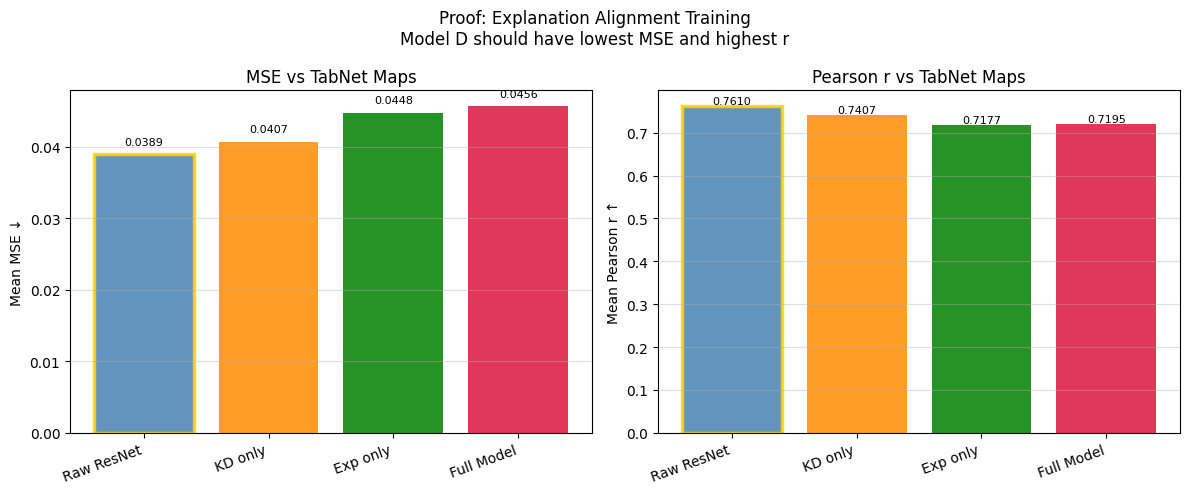

Saved: proof_alignment_scores.png, alignment_scores.csv


In [20]:
def get_activation_cam_224(model, img_tensor):
    acts = {}
    h = model.get_gradcam_layer().register_forward_hook(
        lambda m, i, o: acts.update({'f': o.detach()}))
    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(device))
    h.remove()
    cam = F.relu(acts['f'].mean(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cmin, cmax = cam.min(), cam.max()
    return (cam - cmin) / (cmax - cmin + 1e-8) if cmax > cmin else cam

print("Computing alignment scores (this takes ~2 min)...")
alignment_results = {n: {'mse': [], 'pearson': [], 'labels': []}
                     for n in ['A: Raw ResNet','B: KD only','C: Exp only','D: Full Model']}
model_map = {'A: Raw ResNet': model_A, 'B: KD only': model_B,
             'C: Exp only': model_C, 'D: Full Model': model_D}

for idx in range(len(val_kd_dataset_fast)):
    img_tensor, label, _, _ = val_kd_dataset_fast[idx]
    rel_map = val_relevance_maps[idx]
    for name, model in model_map.items():
        cam  = get_activation_cam_224(model, img_tensor)
        mse  = float(np.mean((cam - rel_map) ** 2))
        r, _ = pearsonr(cam.flatten(), rel_map.flatten())
        alignment_results[name]['mse'].append(mse)
        alignment_results[name]['pearson'].append(r)
        alignment_results[name]['labels'].append(label)
    if idx % 100 == 0: print(f"  {idx}/{len(val_kd_dataset_fast)}...")

print("\nAlignment Score Summary:")
print(f"{'Model':25s} | MSE ↓   | Pearson r ↑")
print("-" * 55)
mse_A = np.mean(alignment_results['A: Raw ResNet']['mse'])
pr_A  = np.mean(alignment_results['A: Raw ResNet']['pearson'])
for name in model_map:
    mse_m = np.mean(alignment_results[name]['mse'])
    pr_m  = np.mean(alignment_results[name]['pearson'])
    print(f"{name:25s} | {mse_m:.4f}  | {pr_m:.4f}  "
          f"(Δ MSE {mse_A-mse_m:+.4f}, Δ r {pr_m-pr_A:+.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names   = list(model_map.keys())
colours = ['steelblue','darkorange','green','crimson']
mse_means = [np.mean(alignment_results[n]['mse']) for n in names]
pr_means  = [np.mean(alignment_results[n]['pearson']) for n in names]

for ax, vals, ylabel, title, best_fn in [
    (axes[0], mse_means, "Mean MSE ↓", "MSE vs TabNet Maps", np.argmin),
    (axes[1], pr_means,  "Mean Pearson r ↑", "Pearson r vs TabNet Maps", np.argmax)
]:
    bars = ax.bar(range(4), vals, color=colours, alpha=0.85)
    bars[best_fn(vals)].set_edgecolor('gold'); bars[best_fn(vals)].set_linewidth(2.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels([n.split(':')[-1].strip() for n in names], rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(True, axis='y', alpha=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle("Proof: Explanation Alignment Training\nModel D should have lowest MSE and highest r", fontsize=12)
plt.tight_layout()
plt.savefig("proof_alignment_scores.png", dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame([{'Model': n,
               'Mean_MSE': np.mean(alignment_results[n]['mse']),
               'Mean_Pearson': np.mean(alignment_results[n]['pearson'])}
              for n in names]).to_csv("alignment_scores.csv", index=False)
print("Saved: proof_alignment_scores.png, alignment_scores.csv")

## Summary of Outputs
All results are saved in `/content/`:

| File | Description |
|---|---|
| `evaluation_results.csv` | Full metrics table (APCER, BPCER, ACER, ECE, AUC) |
| `learning_curves.png` | Validation accuracy + loss components |
| `roc_curves.png` | ROC curves for all 5 models |
| `confusion_matrices.png` | Confusion matrices side by side |
| `cross_sensor_GreenBit.csv` | Cross-sensor ACER/ECE results |
| `cross_sensor_CrossMatch.csv` | Cross-sensor ACER/ECE results |
| `proof_alignment_scores.png` | MSE + Pearson r vs TabNet maps |
| `alignment_scores.csv` | Quantitative alignment scores |
| `feature_importance_global.png` | TabNet feature importances |
| `relevance_maps_class_avg.png` | Class-averaged spatial maps |
| `pearson_correlation.png` | Feature-label correlation heatmap |
| `tabnet_teacher.pkl` | Saved TabNet model |
| `best_A/B/C/D.pth` | Saved ResNet-18 weights per condition |
